# Toy Demo: Predictive Entropy and Latent Mahalanobis Typicality

This notebook illustrates the intuition behind the two drift indicators used in LANTERN:
1. Latent Mahalanobis Typicality (LMT): structural deviation from learned class geometry.
2. Predictive Entropy (PE): uncertainty in model predictions.

<img src="data/figs/lmt_pe_demo.png" alt="Toy PE and LMT illustration" width="1200">

**Figure: Illustration of LMT and PE behaviour.**  
Left: LMT: Structural Mahalanobis vs. Traditional Threshold.     
Right: PE: Model Confusion and Voting Probability


The demo uses synthetic 2D latent representations rather than the full IDS pipeline.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.stats import entropy
from sklearn.linear_model import LogisticRegression
from sklearn.covariance import EmpiricalCovariance

np.random.seed(42)

1. Generate reference latent classes

In [3]:
n = 300

class0 = np.random.multivariate_normal(
    mean=[0, 0],
    cov=[[1.0, 0.2], [0.2, 1.0]],
    size=n
)

class1 = np.random.multivariate_normal(
    mean=[4, 4],
    cov=[[1.0, -0.2], [-0.2, 1.0]],
    size=n
)

X_ref = np.vstack([class0, class1])
y_ref = np.array([0] * n + [1] * n)

2. Train a simple classifier

In [4]:
clf = LogisticRegression()
clf.fit(X_ref, y_ref)

LogisticRegression()

3. Create 3 test regimes

In [5]:
stable = np.random.multivariate_normal(
    mean=[0.2, 0.1],
    cov=[[1.0, 0.2], [0.2, 1.0]],
    size=150
)

uncertain = np.random.multivariate_normal(
    mean=[2.0, 2.0],
    cov=[[0.8, 0.0], [0.0, 0.8]],
    size=150
)

structural_shift = np.random.multivariate_normal(
    mean=[0.0, 5.0],
    cov=[[1.2, 0.4], [0.4, 1.2]],
    size=150
)

blocks = {
    "Stable": stable,
    "Uncertain boundary": uncertain,
    "Structural shift": structural_shift,
}

4. Compute PE and LMT

In [6]:
def predictive_entropy(model, X):
    probs = model.predict_proba(X)
    return entropy(probs.T).mean()

In [7]:
def fit_lmt_reference(X, y):
    refs = {}
    for c in np.unique(y):
        Xc = X[y == c]
        mu = Xc.mean(axis=0)
        cov = EmpiricalCovariance().fit(Xc).covariance_
        cov += 1e-6 * np.eye(cov.shape[0])
        inv_cov = np.linalg.inv(cov)
        refs[c] = (mu, inv_cov)
    return refs

def lmt_score(X, refs, model):
    preds = model.predict(X)
    scores = []
    for x, c in zip(X, preds):
        mu, inv_cov = refs[c]
        diff = x - mu
        scores.append(diff @ inv_cov @ diff.T)
    return np.mean(scores)

lmt_refs = fit_lmt_reference(X_ref, y_ref)

5. Compare Scores

In [8]:
rows = []

for name, X in blocks.items():
    rows.append({
        "Block": name,
        "PE": predictive_entropy(clf, X),
        "LMT": lmt_score(X, lmt_refs, clf),
    })

import pandas as pd
df = pd.DataFrame(rows)
df

,Block,PE,LMT
0,Stable,0.023133,2.123282
1,Uncertain boundary,0.369530,5.481907
2,Structural shift,0.261705,16.546838


6. Visualization

In [9]:
# Color palette
COLORS = {
    "dark_blue": "#34669A",
    "orange": "#E0795F",
    "light_blue": "#86BAD4",
    "light_orange": "#F5B783",
    "pink": "#F4C5C3",
    "red": "#B00A0B",
    "blue_green": "#299d8f",
}

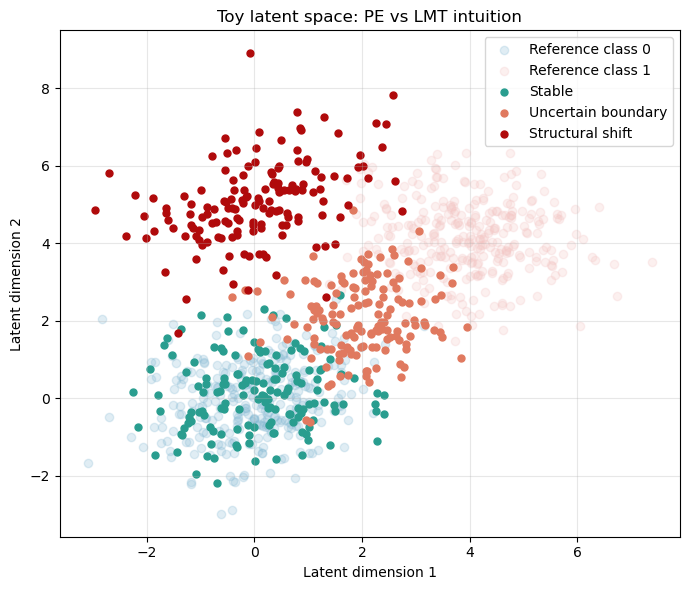

In [10]:
plt.figure(figsize=(7, 6))

# Reference distributions (faded)
plt.scatter(
    class0[:, 0], class0[:, 1],
    alpha=0.25,
    color=COLORS["light_blue"],
    label="Reference class 0"
)

plt.scatter(
    class1[:, 0], class1[:, 1],
    alpha=0.25,
    color=COLORS["pink"],
    label="Reference class 1"
)

# Test blocks (stronger colors)
block_colors = {
    "Stable": COLORS["blue_green"],
    "Uncertain boundary": COLORS["orange"],
    "Structural shift": COLORS["red"],
}

for name, X in blocks.items():
    plt.scatter(
        X[:, 0], X[:, 1],
        s=25,
        color=block_colors.get(name, COLORS["dark_blue"]),
        label=name
    )

plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("Toy latent space: PE vs LMT intuition")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3723882/2020257132.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot.index, rotation=0)
/tmp/ipykernel_3723882/2020257132.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot.index, rotation=0)


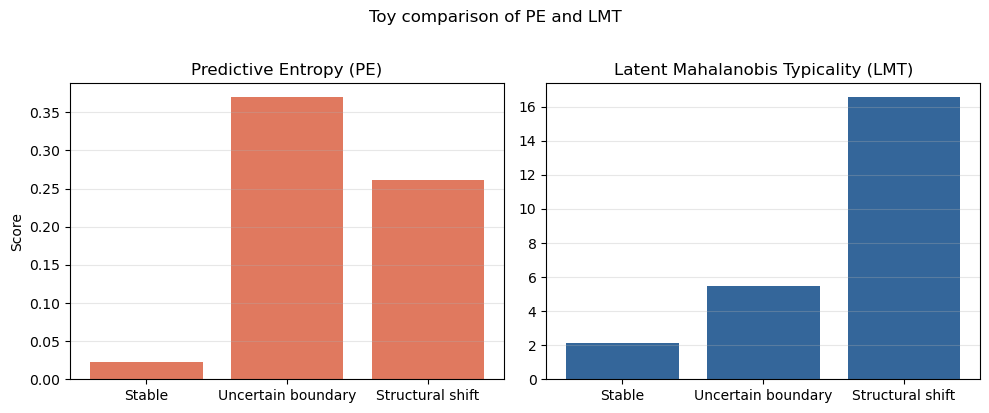

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

df_plot = df.set_index("Block")

# --- PE subplot ---
axes[0].bar(
    df_plot.index,
    df_plot["PE"],
    color=COLORS["orange"]
)
axes[0].set_title("Predictive Entropy (PE)")
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.3)

# --- LMT subplot ---
axes[1].bar(
    df_plot.index,
    df_plot["LMT"],
    color=COLORS["dark_blue"]
)
axes[1].set_title("Latent Mahalanobis Typicality (LMT)")
axes[1].grid(axis="y", alpha=0.3)

# --- shared formatting ---
for ax in axes:
    ax.set_xticklabels(df_plot.index, rotation=0)

plt.suptitle("Toy comparison of PE and LMT", y=1.02)
plt.tight_layout()
plt.show()

The uncertain boundary block has high PE because samples lie near the classifier decision boundary. However, the samples may still lie between known class regions, so the structural deviation measured by LMT is moderate.

The structural-shift block has high LMT because samples are far from the learned class geometry. PE may or may not be high, depending on whether the classifier remains confident. 

This illustrates why LMT and PE are complementary: PE captures uncertainty in the prediction space, while LMT captures deformation in the latent representation space.